<a href="https://colab.research.google.com/github/Chimatanagagopal/DEEP-LEARNING_practice/blob/main/YOLO_Detection%26Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install ultralytics -q
!pip install -U --force-reinstall pillow
import ultralytics
print(f"Ultralytics version: {ultralytics.__version__}")
ultralytics.checks()

Ultralytics 8.4.155 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 48.0/112.6 GB disk)


In [18]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

model = YOLO("yolov8n.pt")
# print("YOLOv8 loaded!")
# print(f"Model type: {type(model)}")

image_path = "/content/objects.jpeg"

results = model(image_path)
print("results",results[0].boxes)
print(f"\nDetections found: {len(results[0].boxes)}")
print(f"\nDetected objects:")
for box in results[0].boxes:
    class_id   = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    print(f"  {class_name} confidence: {confidence:.2f}")



image 1/1 /content/objects.jpeg: 640x608 1 clock, 1 scissors, 7.5ms
Speed: 1.8ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 608)
results ultralytics.engine.results.Boxes object with attributes:

cls: tensor([74., 76.], device='cuda:0')
conf: tensor([0.9536, 0.5963], device='cuda:0')
data: tensor([[192.4416, 391.4933, 327.6945, 526.4852,   0.9536,  74.0000],
        [ 40.4099, 199.5417, 115.2434, 347.9236,   0.5963,  76.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (573, 536)
shape: torch.Size([2, 6])
xywh: tensor([[260.0680, 458.9893, 135.2529, 134.9920],
        [ 77.8267, 273.7327,  74.8335, 148.3819]], device='cuda:0')
xywhn: tensor([[0.4852, 0.8010, 0.2523, 0.2356],
        [0.1452, 0.4777, 0.1396, 0.2590]], device='cuda:0')
xyxy: tensor([[192.4416, 391.4933, 327.6945, 526.4852],
        [ 40.4099, 199.5417, 115.2434, 347.9236]], device='cuda:0')
xyxyn: tensor([[0.3590, 0.6832, 0.6114, 0.9188],
        [0.0754, 0.3482, 0.2150, 0.6

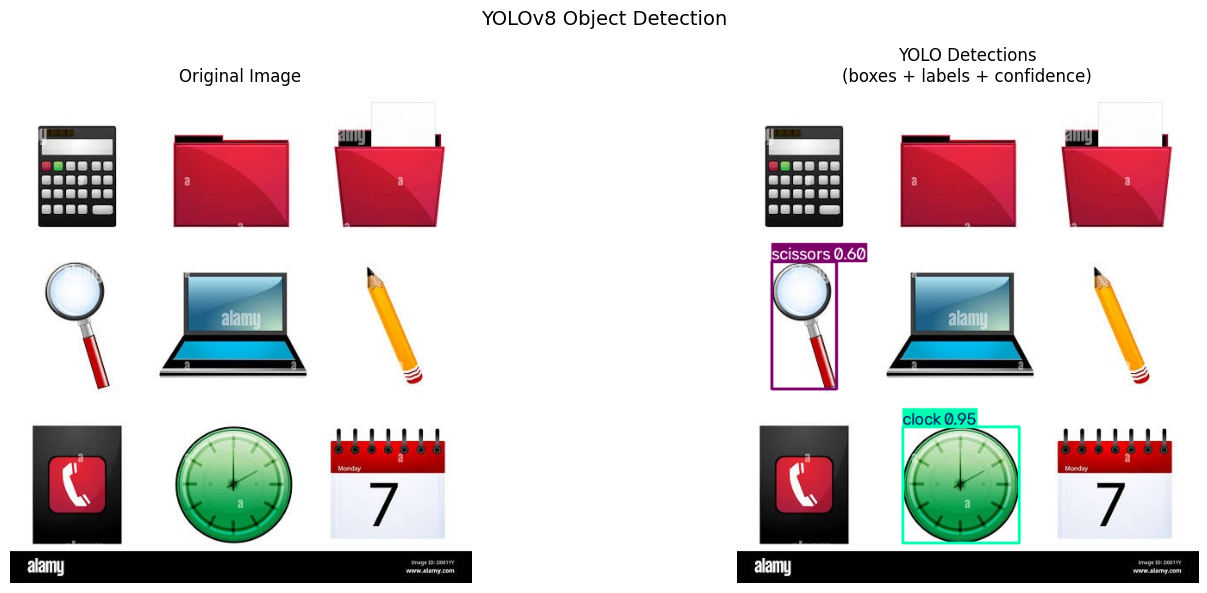

In [19]:
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

annotated = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(annotated_rgb)
axes[1].set_title("YOLO Detections\n(boxes + labels + confidence)")
axes[1].axis("off")

plt.suptitle("YOLOv8 Object Detection", fontsize=14)
plt.tight_layout()
plt.show()

Image size: 536×573

Object          Confidence              Box (x1,y1,x2,y2)
------------------------------------------------------------
clock                 0.95      (192,391) → (327,526)
               box size: 135×135 pixels


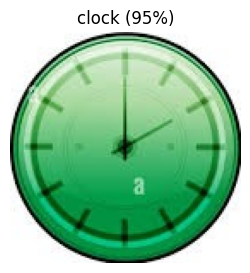

scissors              0.60      (40,199) → (115,347)
               box size: 75×148 pixels


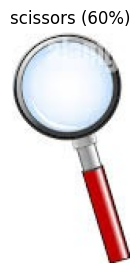

In [21]:
img_rgb  = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
h, w     = img_rgb.shape[:2]

print(f"Image size: {w}×{h}\n")
print(f"{'Object':<15} {'Confidence':>10} {'Box (x1,y1,x2,y2)':>30}")
print("-" * 60)

for i, box in enumerate(results[0].boxes):
    class_id   = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    bw = x2 - x1
    bh = y2 - y1

    print(f"{class_name:<15} {confidence:>10.2f} "
          f"     ({x1},{y1}) → ({x2},{y2})")
    print(f"               box size: {bw}×{bh} pixels")

    cropped = img_rgb[y1:y2, x1:x2]

    plt.figure(figsize=(3, 3))
    plt.imshow(cropped)
    plt.title(f"{class_name} ({confidence:.0%})")
    plt.axis("off")
    plt.show()


image 1/1 /content/objects.jpeg: 640x608 1 clock, 1 scissors, 7.5ms
Speed: 2.8ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 608)
AI Creative Studio — Quality Validator
✅ Objects detected: 2
   → clock           95% confidence
   → scissors        60% confidence

✅ All detections high confidence


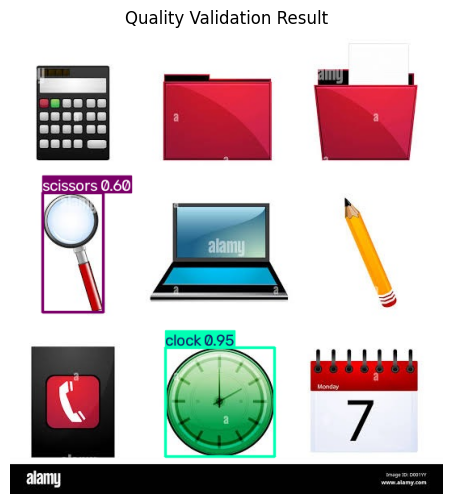

True

In [24]:
def validate_poster_quality(image_path, required_objects=None):

    model  = YOLO("yolov8n.pt")
    result = model(image_path)[0]

    detected = []
    for box in result.boxes:
        class_id   = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        detected.append({
            "object":     class_name,
            "confidence": confidence
        })

    print("=" * 50)
    print("AI Creative Studio — Quality Validator")
    print("=" * 50)

    if len(detected) == 0:
        print("❌ FAIL → No objects detected in image")
        return False

    print(f"✅ Objects detected: {len(detected)}")
    for d in detected:
        print(f"   → {d['object']:<15} {d['confidence']:.0%} confidence")

    low_confidence = [d for d in detected if d["confidence"] < 0.5]
    if low_confidence:
        print(f"\n⚠️  Warning → {len(low_confidence)} object(s) "
              f"detected with low confidence")
        for d in low_confidence:
            print(f"   → {d['object']}: {d['confidence']:.0%}")
    else:
        print("\n✅ All detections high confidence")

    annotated     = result.plot()
    annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(annotated_rgb)
    plt.title("Quality Validation Result")
    plt.axis("off")
    plt.show()

    return len(detected) > 0

validate_poster_quality(image_path)

In [26]:
!wget -O test_image.jpg "https://ultralytics.com/images/bus.jpg"
sample_image = "test_image.jpg"

--2026-09-18 08:14:50--  https://ultralytics.com/images/bus.jpg
Resolving ultralytics.com (ultralytics.com)... 216.150.1.1
Connecting to ultralytics.com (ultralytics.com)|216.150.1.1|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://www.ultralytics.com/images/bus.jpg [following]
--2026-09-18 08:14:50--  https://www.ultralytics.com/images/bus.jpg
Resolving www.ultralytics.com (www.ultralytics.com)... 216.150.16.129, 216.150.1.129
Connecting to www.ultralytics.com (www.ultralytics.com)|216.150.16.129|:443... connected.
HTTP request sent, awaiting response... 308 Permanent Redirect
Location: https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg [following]
--2026-09-18 08:14:50--  https://github.com/ultralytics/assets/releases/download/v0.0.0/bus.jpg
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Locat

Segmentation model loaded!

image 1/1 /content/test_image.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 8.9ms
Speed: 8.6ms preprocess, 8.9ms inference, 48.6ms postprocess per image at shape (1, 3, 640, 480)


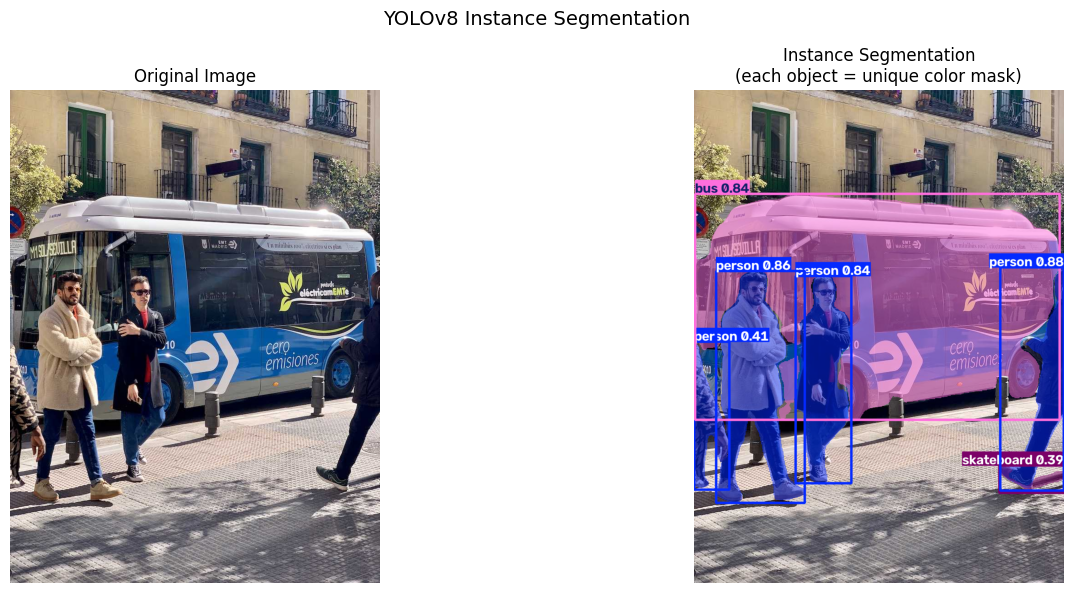


Objects segmented: 6
  → person          88% confidence
  → person          86% confidence
  → person          84% confidence
  → bus             84% confidence
  → person          41% confidence
  → skateboard      39% confidence


In [27]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

seg_model = YOLO("yolov8n-seg.pt")
print("Segmentation model loaded!")




results = seg_model(sample_image)

img_bgr       = cv2.imread(sample_image)
img_rgb       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
annotated     = results[0].plot()
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(annotated_rgb)
axes[1].set_title("Instance Segmentation\n(each object = unique color mask)")
axes[1].axis("off")

plt.suptitle("YOLOv8 Instance Segmentation", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nObjects segmented: {len(results[0].boxes)}")
for box in results[0].boxes:
    class_id   = int(box.cls[0])
    class_name = seg_model.names[class_id]
    confidence = float(box.conf[0])
    print(f"  → {class_name:<15} {confidence:.0%} confidence")


image 1/1 /content/test_image.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 9.6ms
Speed: 2.2ms preprocess, 9.6ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)
Number of masks: 6
Mask shape:      (640, 480)


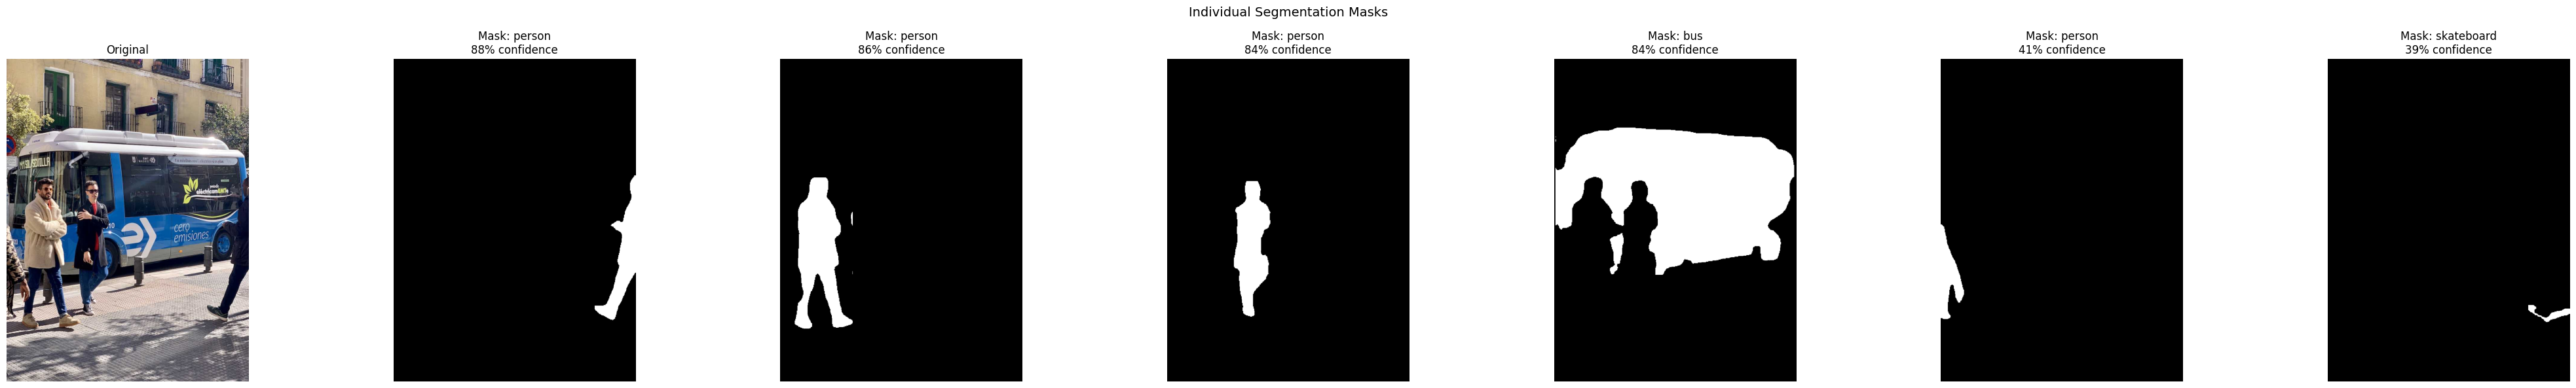

In [28]:
results    = seg_model(sample_image)
img_bgr    = cv2.imread(sample_image)
img_rgb    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w       = img_rgb.shape[:2]

if results[0].masks is not None:
    masks = results[0].masks.data.cpu().numpy()

    print(f"Number of masks: {len(masks)}")
    print(f"Mask shape:      {masks[0].shape}")

    fig, axes = plt.subplots(1, len(masks)+1,
                              figsize=(6*(len(masks)+1), 6))

    if len(masks) == 1:
        axes = [axes]

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    for i, mask in enumerate(masks):
        class_id   = int(results[0].boxes[i].cls[0])
        class_name = seg_model.names[class_id]
        confidence = float(results[0].boxes[i].conf[0])

        mask_resized = cv2.resize(
            mask, (w, h),
            interpolation=cv2.INTER_NEAREST
        )

        axes[i+1].imshow(mask_resized, cmap="gray")
        axes[i+1].set_title(
            f"Mask: {class_name}\n{confidence:.0%} confidence"
        )
        axes[i+1].axis("off")

    plt.suptitle("Individual Segmentation Masks", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No masks detected — try a clearer image")

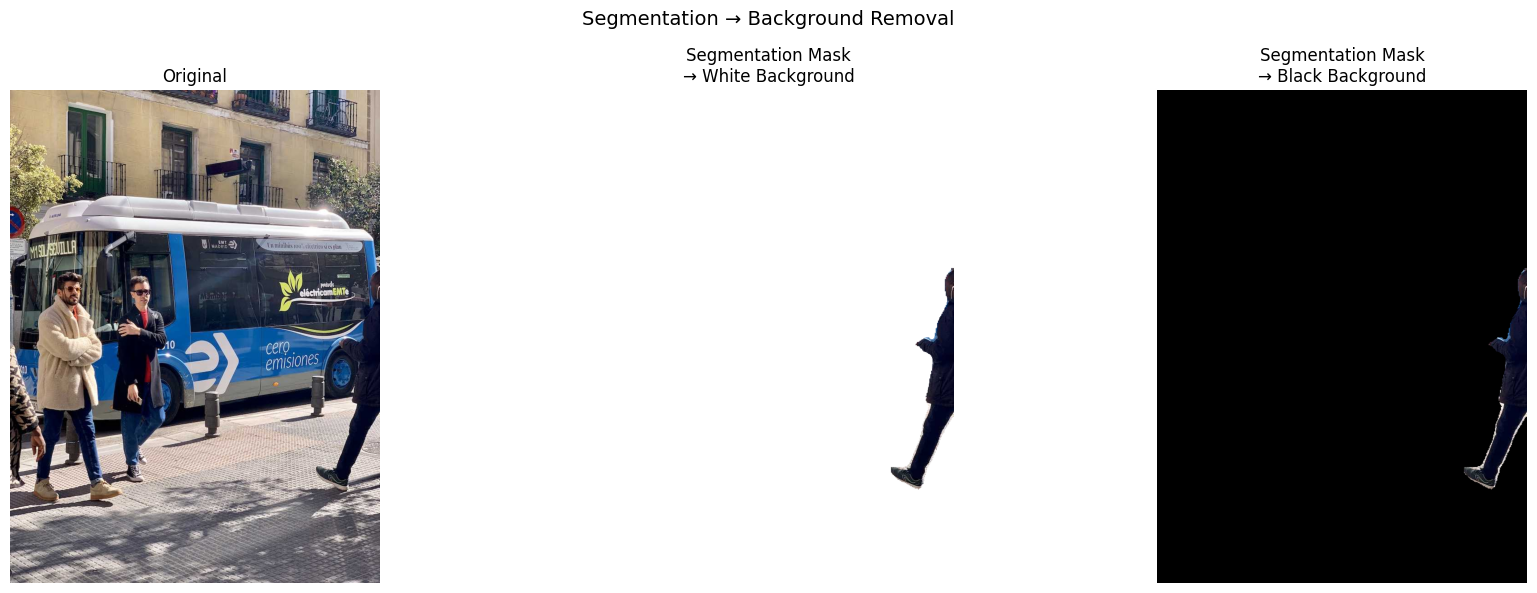

Segmentation mask quality:
  Foreground pixels: 21775
  Background pixels: 853025
  Foreground ratio:  2.5%


In [29]:
if results[0].masks is not None:
    mask       = results[0].masks.data.cpu().numpy()[0]
    mask_resized = cv2.resize(
        mask, (w, h),
        interpolation=cv2.INTER_NEAREST
    ).astype(np.uint8)

    white_bg = np.full_like(img_rgb, 255)
    black_bg = np.zeros_like(img_rgb)

    alpha        = mask_resized[:, :, np.newaxis]
    white_result = (img_rgb * alpha +
                    white_bg * (1 - alpha)).astype(np.uint8)
    black_result = (img_rgb * alpha +
                    black_bg * (1 - alpha)).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(white_result)
    axes[1].set_title("Segmentation Mask\n→ White Background")
    axes[1].axis("off")

    axes[2].imshow(black_result)
    axes[2].set_title("Segmentation Mask\n→ Black Background")
    axes[2].axis("off")

    plt.suptitle("Segmentation → Background Removal", fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Segmentation mask quality:")
    print(f"  Foreground pixels: {mask_resized.sum()}")
    print(f"  Background pixels: {(1-mask_resized).sum()}")
    print(f"  Foreground ratio:  "
          f"{mask_resized.sum()/(w*h):.1%}")


image 1/1 /content/test_image.jpg: 640x480 4 persons, 1 bus, 1 skateboard, 19.9ms
Speed: 6.7ms preprocess, 19.9ms inference, 4.6ms postprocess per image at shape (1, 3, 640, 480)


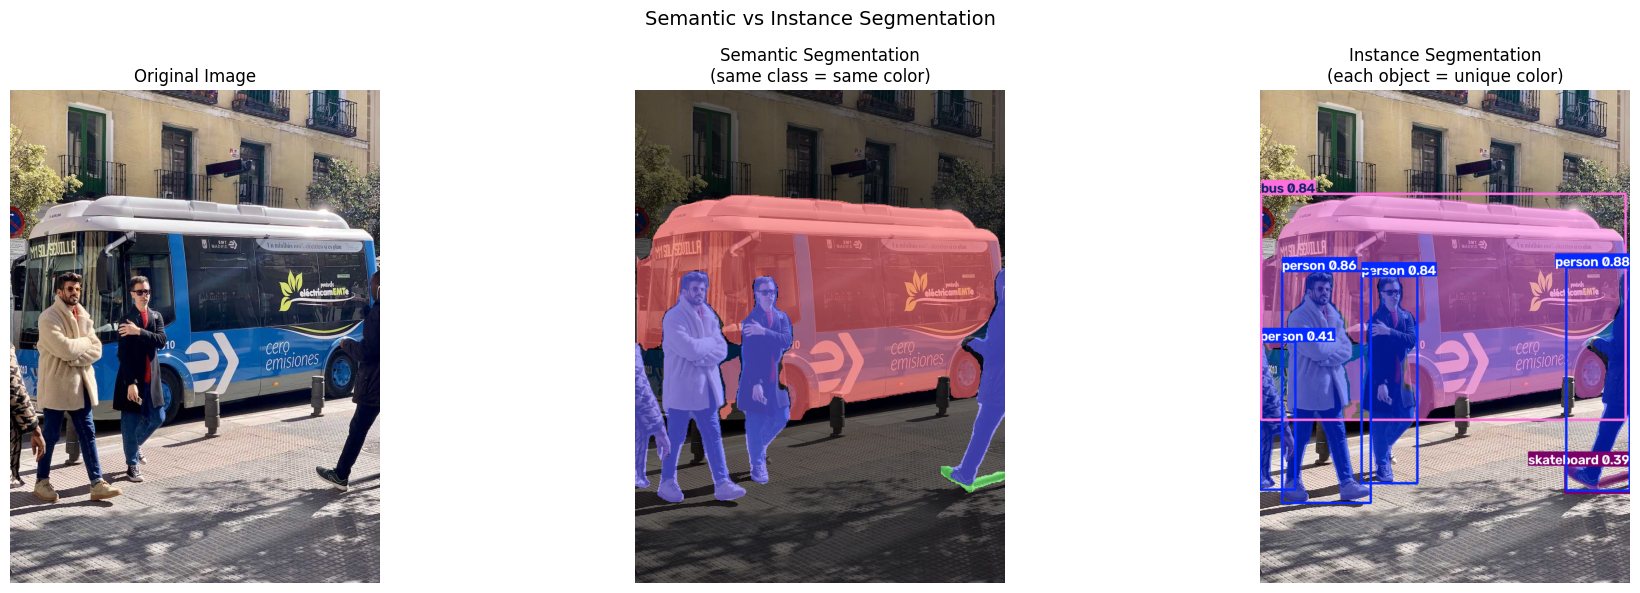

Semantic coloring:
  person          → RGB(100, 100, 255)
  bus             → RGB(255, 100, 100)
  skateboard      → RGB(100, 255, 100)


In [30]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt

seg_model    = YOLO("yolov8n-seg.pt")
sample_image = "test_image.jpg"
results      = seg_model(sample_image)

img_bgr = cv2.imread(sample_image)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
h, w    = img_rgb.shape[:2]

CLASS_COLORS = {
    "bus"        : [255, 100, 100],
    "person"     : [100, 100, 255],
    "skateboard" : [100, 255, 100],
    "car"        : [255, 165,   0],
    "truck"      : [128,   0, 128],
}
DEFAULT_COLOR = [200, 200, 200]

semantic_mask = np.zeros_like(img_rgb)
instance_mask = results[0].plot()
instance_mask = cv2.cvtColor(instance_mask, cv2.COLOR_BGR2RGB)

if results[0].masks is not None:
    for i, mask in enumerate(results[0].masks.data.cpu().numpy()):
        class_id   = int(results[0].boxes[i].cls[0])
        class_name = seg_model.names[class_id]

        color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)

        mask_resized = cv2.resize(
            mask, (w, h),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool)

        semantic_mask[mask_resized] = color

semantic_overlay = (img_rgb * 0.4 + semantic_mask * 0.6).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].imshow(img_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(semantic_overlay)
axes[1].set_title("Semantic Segmentation\n(same class = same color)")
axes[1].axis("off")

axes[2].imshow(instance_mask)
axes[2].set_title("Instance Segmentation\n(each object = unique color)")
axes[2].axis("off")

plt.suptitle("Semantic vs Instance Segmentation", fontsize=14)
plt.tight_layout()
plt.show()

print("Semantic coloring:")
detected_classes = set()
for box in results[0].boxes:
    class_name = seg_model.names[int(box.cls[0])]
    if class_name not in detected_classes:
        color = CLASS_COLORS.get(class_name, DEFAULT_COLOR)
        print(f"  {class_name:<15} → RGB{tuple(color)}")
        detected_classes.add(class_name)

In [34]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install opencv-contrib-python

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.1/82.1 MB 9.9 MB/s eta 0:00:00


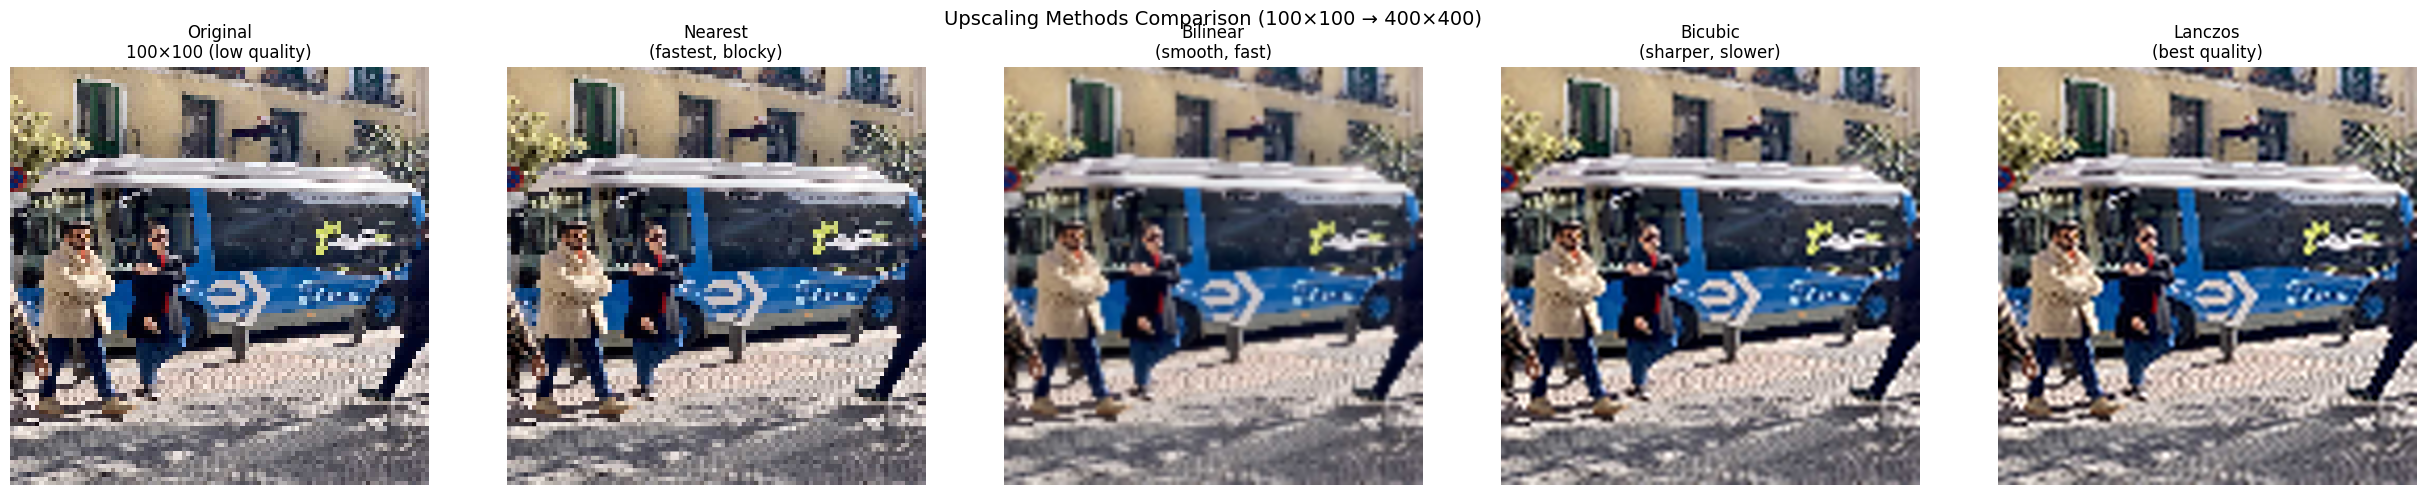

Method comparison:
  Nearest  → fastest  but blocky pixels
  Bilinear → smooth   but slightly blurry
  Bicubic  → sharper  good balance
  Lanczos  → best     quality, use this for products


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread("test_image.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

small = cv2.resize(img_rgb, (100, 100))

nearest  = cv2.resize(small, (400, 400),
                      interpolation=cv2.INTER_NEAREST)
bilinear = cv2.resize(small, (400, 400),
                      interpolation=cv2.INTER_LINEAR)

bicubic  = cv2.resize(small, (400, 400),
                      interpolation=cv2.INTER_CUBIC)
lanczos  = cv2.resize(small, (400, 400),
                      interpolation=cv2.INTER_LANCZOS4)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(small)
axes[0].set_title("Original\n100×100 (low quality)")
axes[0].axis("off")

axes[1].imshow(nearest)
axes[1].set_title("Nearest\n(fastest, blocky)")
axes[1].axis("off")

axes[2].imshow(bilinear)
axes[2].set_title("Bilinear\n(smooth, fast)")
axes[2].axis("off")

axes[3].imshow(bicubic)
axes[3].set_title("Bicubic\n(sharper, slower)")
axes[3].axis("off")

axes[4].imshow(lanczos)
axes[4].set_title("Lanczos\n(best quality)")
axes[4].axis("off")

plt.suptitle("Upscaling Methods Comparison (100×100 → 400×400)",
             fontsize=14)
plt.tight_layout()
plt.show()

print("Method comparison:")
print(f"  Nearest  → fastest  but blocky pixels")
print(f"  Bilinear → smooth   but slightly blurry")
print(f"  Bicubic  → sharper  good balance")
print(f"  Lanczos  → best     quality, use this for products")

In [2]:
!pip uninstall -y opencv-python opencv-contrib-python
!pip install opencv-contrib-python

Found existing installation: opencv-contrib-python 5.0.0.93
Uninstalling opencv-contrib-python-5.0.0.93:
  Successfully uninstalled opencv-contrib-python-5.0.0.93
  Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
Using cached opencv_contrib_python-5.0.0.93-cp37-abi3-manylinux_2_28_x86_64.whl (82.1 MB)


Running AI upscaling...
Done! (150, 150) → (600, 600)


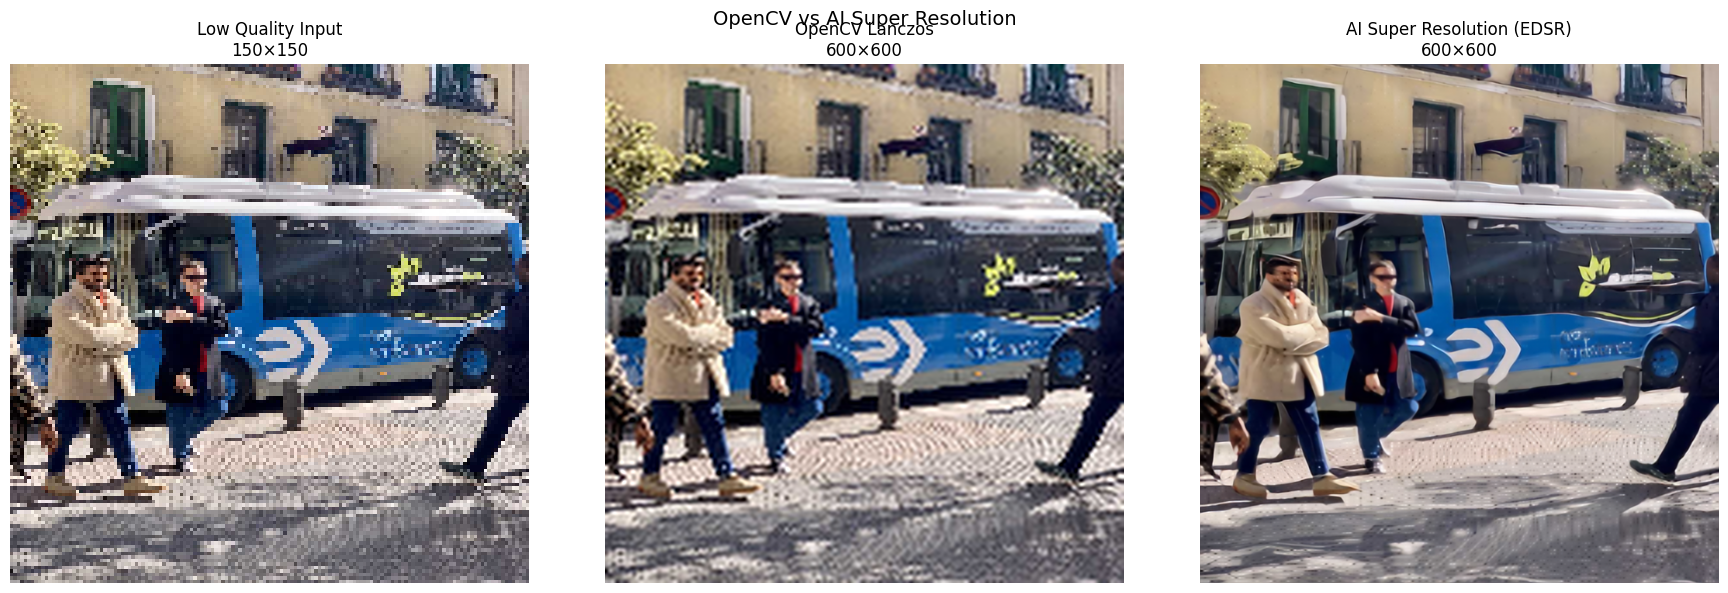

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

model_url  = "https://github.com/Saafke/EDSR_Tensorflow/raw/master/models/EDSR_x4.pb"
model_path = "EDSR_x4.pb"

if not os.path.exists(model_path):
    print("Downloading AI upscaling model...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Downloaded!")

sr = cv2.dnn_superres.DnnSuperResImpl_create()
sr.readModel(model_path)
sr.setModel("edsr", 4)

img_bgr = cv2.imread("test_image.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
small   = cv2.resize(img_rgb, (150, 150))
small_bgr = cv2.cvtColor(small, cv2.COLOR_RGB2BGR)

print("Running AI upscaling...")
upscaled_bgr = sr.upsample(small_bgr)
upscaled_rgb = cv2.cvtColor(upscaled_bgr, cv2.COLOR_BGR2RGB)
print(f"Done! {small.shape[:2]} → {upscaled_rgb.shape[:2]}")

opencv_upscaled = cv2.resize(small, (600, 600),
                              interpolation=cv2.INTER_LANCZOS4)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(small)
axes[0].set_title(f"Low Quality Input\n{small.shape[1]}×{small.shape[0]}")
axes[0].axis("off")

axes[1].imshow(opencv_upscaled)
axes[1].set_title(f"OpenCV Lanczos\n{opencv_upscaled.shape[1]}×{opencv_upscaled.shape[0]}")
axes[1].axis("off")

axes[2].imshow(upscaled_rgb)
axes[2].set_title(f"AI Super Resolution (EDSR)\n{upscaled_rgb.shape[1]}×{upscaled_rgb.shape[0]}")
axes[2].axis("off")

plt.suptitle("OpenCV vs AI Super Resolution", fontsize=14)
plt.tight_layout()
plt.show()

Input size:  810×1080
Already large enough → just resize to 512×512


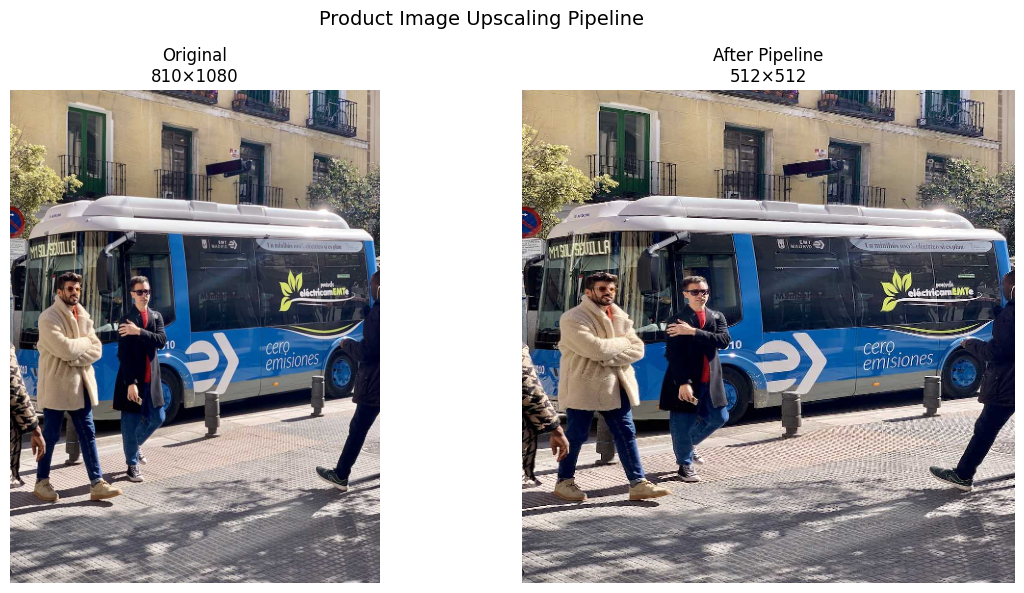

In [2]:
def upscale_product_image(image_path, target_size=512):

    img_bgr = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w    = img_rgb.shape[:2]

    print(f"Input size:  {w}×{h}")

    if max(h, w) >= target_size:
        print(f"Already large enough → just resize to {target_size}×{target_size}")
        result = cv2.resize(img_rgb, (target_size, target_size),
                            interpolation=cv2.INTER_LANCZOS4)
        return result

    scale_needed = target_size / max(h, w)
    print(f"Scale needed: {scale_needed:.1f}x")

    if scale_needed <= 2:
        print("Using Lanczos (scale ≤ 2x)")
        result = cv2.resize(img_rgb,
                            (target_size, target_size),
                            interpolation=cv2.INTER_LANCZOS4)
    else:
        print("Using AI Super Resolution (scale > 2x)")
        img_bgr_small  = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        upscaled_bgr   = sr.upsample(img_bgr_small)
        upscaled_rgb   = cv2.cvtColor(upscaled_bgr, cv2.COLOR_BGR2RGB)
        result = cv2.resize(upscaled_rgb,
                            (target_size, target_size),
                            interpolation=cv2.INTER_LANCZOS4)

    print(f"Output size: {result.shape[1]}×{result.shape[0]}")
    return result

result = upscale_product_image("test_image.jpg", target_size=512)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

original = cv2.cvtColor(cv2.imread("test_image.jpg"), cv2.COLOR_BGR2RGB)
axes[0].imshow(original)
axes[0].set_title(f"Original\n{original.shape[1]}×{original.shape[0]}")
axes[0].axis("off")

axes[1].imshow(result)
axes[1].set_title(f"After Pipeline\n{result.shape[1]}×{result.shape[0]}")
axes[1].axis("off")

plt.suptitle("Product Image Upscaling Pipeline", fontsize=14)
plt.tight_layout()
plt.show()